# KaburAjaDulu AI - End-to-End Data Preparation

Notebook ini disusun berurutan dari atas ke bawah agar alurnya mudah diikuti:
1. Pertanyaan bisnis
2. Import library
3. Assessing data
4. Cleaning data
5. Exploratory Data Analysis (EDA)
6. Visualisasi
7. Penyimpanan output akhir

Fokus analisis diarahkan ke industri IT agar tidak terlalu general dan hasilnya relevan untuk tim AI Engineer.

## Pertanyaan Bisnis

Pertanyaan bisnis berikut mengikuti kriteria specific, measurable, action-oriented, relevant, dan time-bound. Karena dataset tidak memiliki timestamp yang konsisten untuk dipakai sebagai analisis waktu, maka fokusnya adalah keseluruhan data yang tersedia saat ini.

1. Skill teknis apa saja yang paling sering muncul pada lowongan IT di dataset ini, dan berapa persentase kemunculan masing-masing skill terhadap total lowongan IT?
2. Untuk setiap role IT utama di dataset, skill apa yang paling sering diminta oleh lowongan tetapi paling jarang muncul pada resume kandidat, dan seberapa besar gap-nya dalam persentase?
3. Role IT mana yang memiliki ketidakseimbangan supply-demand paling tinggi, diukur dari rasio jumlah resume IT terhadap jumlah lowongan IT, sehingga dapat diprioritaskan dalam rekomendasi pengembangan karier?

## Import Library

Sebelum data dibaca dan diproses, kita perlu mengimpor library yang akan dipakai untuk manipulasi data, analisis, visualisasi, dan penyimpanan hasil akhir. Seluruh proses berikut menggunakan library standar yang umum dipakai dalam data science.

In [12]:
from pathlib import Path
import re
import gdown

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from job_it import IT_TITLE_PATTERNS, SKILL_CATALOG

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', palette='deep')

BASE_DIR = Path('.')
DATA_DIR = BASE_DIR / 'data'
OUTPUT_DIR = BASE_DIR / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Library import complete.')
print(f'Output directory: {OUTPUT_DIR.resolve()}')

Library import complete.
Output directory: /home/knowrise/DATA/Programming/capstone-project-data-science-2/output


## Assessing Data

Langkah ini dipakai untuk memahami struktur data mentah sebelum dibersihkan. Kita akan melihat ukuran data, tipe kolom, nilai hilang, dan indikasi duplikasi agar tahu bagian mana yang butuh perhatian lebih dulu.

In [14]:
job_path = DATA_DIR / 'job-postings' / 'postings.csv'
resume_path = DATA_DIR / 'resumes' / 'resume.csv'

job_df = pd.read_csv(job_path)
resume_df = pd.read_csv(resume_path)

print('Job postings shape:', job_df.shape)
print('Resume shape:', resume_df.shape)

print('\nJob postings info:')
job_df.info()

print('\nResume info:')
resume_df.info()

Job postings shape: (123849, 31)
Resume shape: (2484, 4)

Job postings info:
<class 'pandas.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  str    
 2   title                       123849 non-null  str    
 3   description                 123842 non-null  str    
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   str    
 6   location                    123849 non-null  str    
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  str    
 12  applie

### Assessing Kualitas Data

Di tahap ini kita cek duplikasi, missing value, dan kolom-kolom penting yang akan dipakai di tahap analisis. Hasilnya dipakai untuk menentukan cleaning apa saja yang perlu dilakukan.

In [25]:
job_assess = pd.DataFrame({
    'metric': ['rows', 'duplicates', 'missing_title', 'missing_description', 'missing_company_name', 'missing_salary_range', 'missing_experience_level', 'missing_skills_desc'],
    'value': [
        len(job_df),
        int(job_df.duplicated().sum()),
        int(job_df['title'].isna().sum()),
        int(job_df['description'].isna().sum()),
        int(job_df['company_name'].isna().sum()),
        int(job_df['min_salary'].isna().sum()),
        int(job_df['formatted_experience_level'].isna().sum()),
        int(job_df['skills_desc'].isna().sum()),
    ]
})
job_assess['pct'] = job_assess['value'] / len(job_df) * 100

resume_assess = pd.DataFrame({
    'metric': ['rows', 'duplicates', 'missing_resume_str', 'missing_resume_html', 'missing_category'],
    'value': [
        len(resume_df),
        int(resume_df.duplicated().sum()),
        int(resume_df['Resume_str'].isna().sum()),
        int(resume_df['Resume_html'].isna().sum()),
        int(resume_df['Category'].isna().sum()),
    ]
})
resume_assess['pct'] = resume_assess['value'] / len(resume_df) * 100

print('Job postings assessment:')
print(job_assess.to_string(index=False))
print('\nResume assessment:')
print(resume_assess.to_string(index=False))

Job postings assessment:
                  metric  value        pct
                    rows 123849 100.000000
              duplicates      0   0.000000
           missing_title      0   0.000000
     missing_description      7   0.005652
    missing_company_name   1719   1.387981
    missing_salary_range  94056  75.944093
missing_experience_level  29409  23.745852
     missing_skills_desc 121410  98.030666

Resume assessment:
             metric  value   pct
               rows   2484 100.0
         duplicates      0   0.0
 missing_resume_str      0   0.0
missing_resume_html      0   0.0
   missing_category      0   0.0


### Assessing Struktur dan Nilai Awal

Selain ringkasan missing value, kita perlu melihat contoh baris awal dan distribusi kategori utama. Ini membantu mengonfirmasi bahwa data yang dibaca sudah sesuai konteks analisis IT.

In [26]:
print('Job postings head:')
print(job_df.head(3).to_string())
print('\nResume head:')
print(resume_df.head(3).to_string())

print('\nJob title top counts:')
print(job_df['title'].value_counts().head(10).to_string())

print('\nResume category counts:')
print(resume_df['Category'].value_counts().to_string())

print('\nJob description length summary:')
print(job_df['description'].fillna('').str.len().describe().to_string())

print('\nResume text length summary:')
print(resume_df['Resume_str'].fillna('').str.len().describe().to_string())

Job postings head:
     job_id            company_name                              title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

## Cleaning Data

Setelah data dipahami, kita mulai membersihkan data mentah. Tahap ini mencakup penyeragaman nama kolom, penghapusan duplikasi, pembuatan kolom teks yang lebih rapi, dan persiapan data sebelum difilter ke industri IT.

In [27]:
job_df = job_df.copy()
resume_df = resume_df.copy()

job_df.columns = job_df.columns.str.strip()
resume_df.columns = resume_df.columns.str.strip()

job_df = job_df.drop_duplicates().reset_index(drop=True)
resume_df = resume_df.drop_duplicates().reset_index(drop=True)

for frame in [job_df, resume_df]:
    for column in frame.select_dtypes(include=['object', 'string']).columns:
        frame[column] = frame[column].astype(str).str.strip()

job_df['title_clean'] = job_df['title'].fillna('').astype(str)
job_df['description_clean'] = job_df['description'].fillna('').astype(str)
resume_df['resume_text'] = resume_df['Resume_str'].fillna('').astype(str)
resume_df['resume_html_text'] = resume_df['Resume_html'].fillna('').astype(str)

print('Cleaned job postings shape:', job_df.shape)
print('Cleaned resume shape:', resume_df.shape)
print('Duplicate rows remaining in job data:', int(job_df.duplicated().sum()))
print('Duplicate rows remaining in resume data:', int(resume_df.duplicated().sum()))

Cleaned job postings shape: (123849, 33)
Cleaned resume shape: (2484, 6)
Duplicate rows remaining in job data: 0
Duplicate rows remaining in resume data: 0


### Cleaning dan Filtering ke Industri IT

Tahap berikutnya adalah memfilter data menjadi domain IT. Di sini kita menggunakan pola judul lowongan untuk lowongan dan kategori resume untuk kandidat, lalu menambahkan klasifikasi role serta ekstraksi skill sebagai dasar analisis lanjutan.

In [28]:
IT_TITLE_REGEX = re.compile('|'.join(f'(?:{pattern})' for pattern in IT_TITLE_PATTERNS), flags=re.IGNORECASE)
ALL_SKILLS = sorted({skill for skills in SKILL_CATALOG.values() for skill in skills})
TECHNICAL_SKILLS = sorted({skill for category, skills in SKILL_CATALOG.items() if category != 'Other' for skill in skills})
TECHNICAL_SKILL_SET = set(TECHNICAL_SKILLS)

ROLE_PATTERNS = {
    'Software Engineering': [r'backend', r'front\s*end', r'frontend', r'full\s*stack', r'software\s+engineer', r'software\s+developer', r'developer', r'platform\s+engineer'],
    'Data & Analytics': [r'data\s+scientist', r'data\s+science', r'machine\s+learning', r'ml\s+engineer', r'data\s+engineer', r'data\s+analyst', r'analytics?', r'business\s+intelligence', r'bi\s+analyst'],
    'DevOps & Cloud': [r'devops', r'site\s+reliability', r'cloud'],
    'Quality Assurance': [r'qa', r'quality\s+assurance', r'tester', r'test\s+engineer'],
    'Mobile Development': [r'mobile', r'android', r'ios', r'flutter', r'react\s+native'],
    'Security': [r'cyber\s+security', r'information\s+security', r'security\s+engineer', r'security\s+analyst', r'security\s+administrator'],
    'IT Support': [r'technical\s+support', r'help\s+desk', r'it\s+support', r'support\s+engineer'],
}
ROLE_REGEX = {role: re.compile('|'.join(f'(?:{pattern})' for pattern in patterns), flags=re.IGNORECASE) for role, patterns in ROLE_PATTERNS.items()}


def normalize_text(value):
    if pd.isna(value):
        return ''
    return str(value).strip()


def build_skill_regex(skill):
    escaped = re.escape(skill).replace(r'\ ', r'\s+')
    return re.compile(rf'(?<!\w){escaped}(?!\w)', flags=re.IGNORECASE)


SKILL_REGEX = {skill: build_skill_regex(skill) for skill in ALL_SKILLS}


def extract_skills(text):
    text = normalize_text(text)
    if not text:
        return []
    return sorted({skill for skill, pattern in SKILL_REGEX.items() if pattern.search(text)})


def classify_role(text, default='Other IT'):
    text = normalize_text(text)
    for role, pattern in ROLE_REGEX.items():
        if pattern.search(text):
            return role
    return default

job_df['it_flag'] = job_df['title_clean'].str.contains(IT_TITLE_REGEX, regex=True, na=False)
job_it = job_df.loc[job_df['it_flag']].copy()
job_it['role_bucket'] = job_it['title_clean'].apply(classify_role)
job_it['skills_extracted'] = job_it['description_clean'].apply(extract_skills)
job_it['skill_count'] = job_it['skills_extracted'].str.len()

resume_df['it_flag'] = resume_df['Category'].fillna('').astype(str).str.upper().eq('INFORMATION-TECHNOLOGY')
resume_it = resume_df.loc[resume_df['it_flag']].copy()
resume_it['role_bucket'] = resume_it['resume_text'].apply(classify_role)
resume_it['skills_extracted'] = resume_it['resume_text'].apply(extract_skills)
resume_it['skill_count'] = resume_it['skills_extracted'].str.len()

print('IT job postings shape:', job_it.shape)
print('IT resume shape:', resume_it.shape)
print('\nTop role buckets in IT job postings:')
print(job_it['role_bucket'].value_counts().to_string())
print('\nTop role buckets in IT resumes:')
print(resume_it['role_bucket'].value_counts().to_string())

IT job postings shape: (9033, 37)
IT resume shape: (120, 10)

Top role buckets in IT job postings:
role_bucket
Software Engineering    4344
Data & Analytics        1784
DevOps & Cloud           842
Quality Assurance        828
IT Support               524
Security                 479
Mobile Development       232

Top role buckets in IT resumes:
role_bucket
Software Engineering    30
Data & Analytics        21
Mobile Development      16
DevOps & Cloud          14
IT Support              12
Quality Assurance       11
Security                 9
Other IT                 7


## Exploratory Data Analysis

Pada tahap ini kita benar-benar mengeksplorasi data yang sudah dibersihkan. Kita tidak langsung menarik kesimpulan, tetapi memeriksa pola, distribusi, hubungan antar variabel, dan perbedaan antara demand lowongan dengan supply kandidat.

### EDA 1 - Kualitas Data Hasil Cleaning

Sebelum melihat pola yang lebih kompleks, kita cek ulang apakah hasil cleaning sudah stabil. Ini membantu memastikan eksplorasi berikutnya dilakukan pada data yang layak dianalisis.

In [29]:
eda_quality = pd.DataFrame({
    'dataset': ['job_it', 'resume_it'],
    'rows': [len(job_it), len(resume_it)],
    'duplicates': [int(job_it.duplicated().sum()), int(resume_it.duplicated().sum())],
    'missing_title_or_text': [int(job_it['description_clean'].eq('').sum()), int(resume_it['resume_text'].eq('').sum())],
    'avg_skill_count': [float(job_it['skill_count'].mean()), float(resume_it['skill_count'].mean())],
})

print(eda_quality.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
quality_missing = pd.DataFrame({
    'job_it': job_it[['title_clean', 'description_clean', 'company_name', 'formatted_experience_level']].replace('', np.nan).isna().mean() * 100,
    'resume_it': resume_it[['resume_text', 'resume_html_text', 'Category']].replace('', np.nan).isna().mean() * 100,
})
quality_missing['job_it'].sort_values().plot.barh(ax=axes[0], color='#4c78a8', title='Missing Value Rate pada job_it (%)')
quality_missing['resume_it'].sort_values().plot.barh(ax=axes[1], color='#f58518', title='Missing Value Rate pada resume_it (%)')
plt.tight_layout()
plt.show()

TypeError: unhashable type: 'list'

### EDA 2 - Distribusi Numerik dan Teks

Berikutnya kita lihat bentuk distribusi variabel numerik utama pada lowongan dan resume. Kita juga cek panjang teks agar tahu apakah dokumen cenderung pendek, sedang, atau panjang.

In [ ]:
job_numeric = job_it[['views', 'applies', 'min_salary', 'max_salary', 'med_salary', 'normalized_salary', 'remote_allowed', 'sponsored']].apply(pd.to_numeric, errors='coerce')
job_text_lengths = pd.DataFrame({
    'text_type': ['title_clean', 'description_clean'],
    'mean_length': [job_it['title_clean'].str.len().mean(), job_it['description_clean'].str.len().mean()],
    'median_length': [job_it['title_clean'].str.len().median(), job_it['description_clean'].str.len().median()],
})
resume_text_lengths = pd.DataFrame({
    'text_type': ['resume_text', 'resume_html_text'],
    'mean_length': [resume_it['resume_text'].str.len().mean(), resume_it['resume_html_text'].str.len().mean()],
    'median_length': [resume_it['resume_text'].str.len().median(), resume_it['resume_html_text'].str.len().median()],
})

print('Job numeric summary:')
print(job_numeric.describe().T.to_string())
print('\nJob text lengths:')
print(job_text_lengths.to_string(index=False))
print('\nResume text lengths:')
print(resume_text_lengths.to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, column in zip(axes.flat, ['views', 'applies', 'min_salary', 'max_salary', 'normalized_salary', 'remote_allowed']):
    sns.histplot(job_numeric[column].dropna(), bins=30, kde=True, ax=ax, color='#4c78a8')
    ax.set_title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

### EDA 3 - Korelasi dan Hubungan Antar Variabel

Tahap ini melihat hubungan linear dan visual antara variabel numerik utama. Korelasi membantu memberi gambaran awal, sedangkan scatter plot dan boxplot memperlihatkan pola yang lebih nyata di data.

In [ ]:
corr_columns = ['views', 'applies', 'min_salary', 'max_salary', 'med_salary', 'normalized_salary', 'remote_allowed', 'sponsored']
corr_df = job_numeric[corr_columns].corr(method='spearman')

plt.figure(figsize=(10, 7))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='Blues', center=0)
plt.title('Korelasi Spearman Fitur Numerik pada Lowongan IT')
plt.tight_layout()
plt.show()

scatter_sample = job_it[['views', 'applies', 'normalized_salary', 'role_bucket']].dropna(subset=['views', 'applies']).sample(n=min(4000, len(job_it.dropna(subset=['views', 'applies']))), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.scatterplot(data=scatter_sample, x='views', y='applies', hue='role_bucket', alpha=0.55, s=35, ax=axes[0], legend=False)
axes[0].set_title('Hubungan Views vs Applies pada Lowongan IT')
axes[0].set_xlabel('Views')
axes[0].set_ylabel('Applies')

salary_box = job_it[['role_bucket', 'normalized_salary']].dropna().copy()
role_order = salary_box.groupby('role_bucket')['normalized_salary'].median().sort_values(ascending=False).index
sns.boxplot(data=salary_box, x='normalized_salary', y='role_bucket', order=role_order, ax=axes[1], color='#72b7b2')
axes[1].set_title('Sebaran Normalized Salary per Role IT')
axes[1].set_xlabel('Normalized Salary')
axes[1].set_ylabel('Role')

plt.tight_layout()
plt.show()

### EDA 4 - Distribusi Role dan Work Type

Setelah melihat hubungan numerik, kita cek komposisi role IT dan tipe kerja. Ini penting untuk mengetahui segmen pasar mana yang paling dominan di data lowongan.

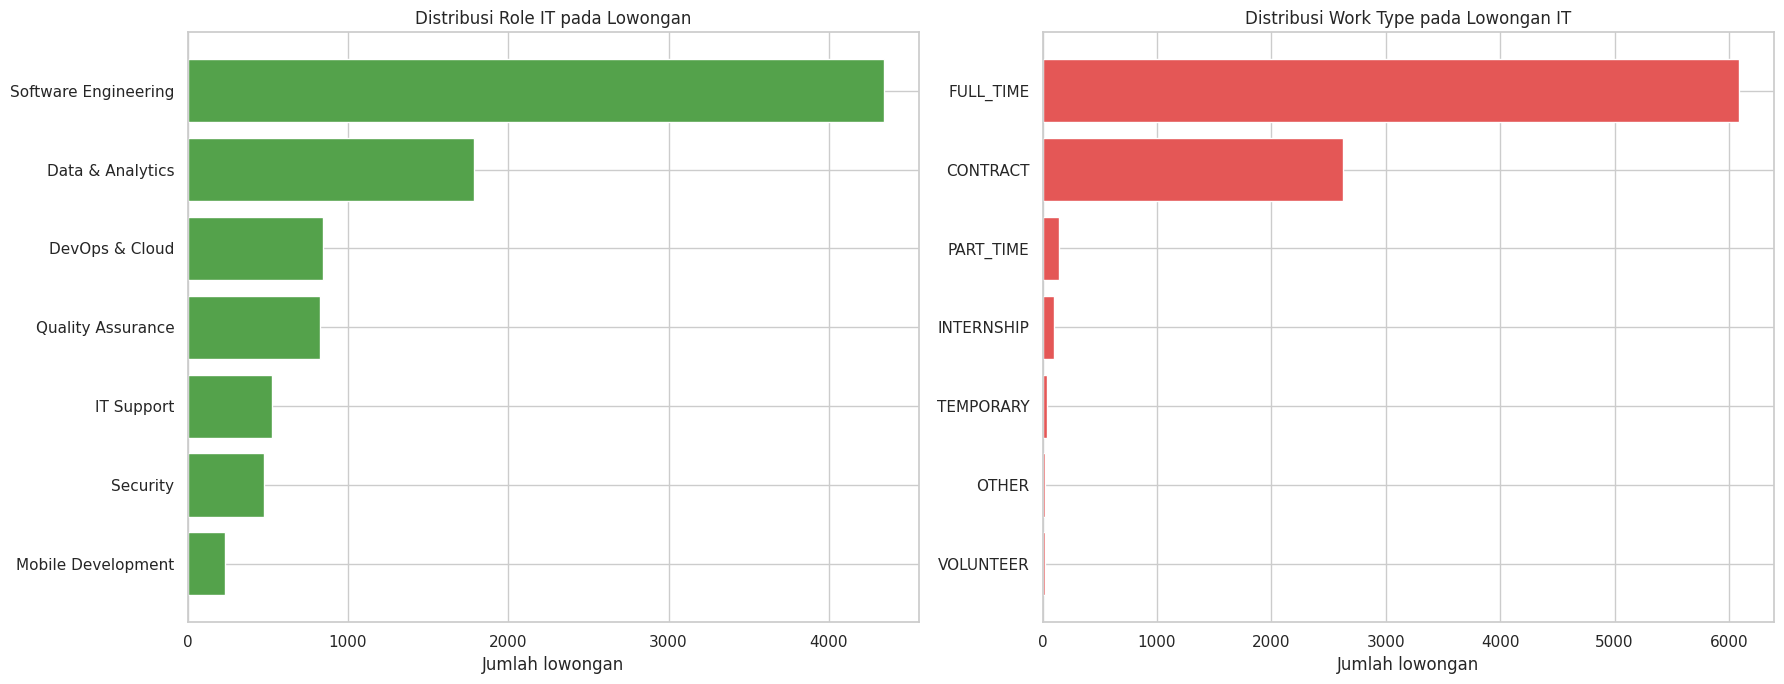

Role counts:
 role_bucket
Mobile Development       232
Security                 479
IT Support               524
Quality Assurance        828
DevOps & Cloud           842
Data & Analytics        1784
Software Engineering    4344

Work type counts:
 work_type
VOLUNTEER       17
OTHER           23
TEMPORARY       36
INTERNSHIP      98
PART_TIME      145
CONTRACT      2624
FULL_TIME     6090


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

role_counts = job_it['role_bucket'].value_counts().sort_values(ascending=True)
axes[0].barh(role_counts.index, role_counts.values, color='#54a24b')
axes[0].set_title('Distribusi Role IT pada Lowongan')
axes[0].set_xlabel('Jumlah lowongan')

work_type_counts = job_it['work_type'].value_counts().sort_values(ascending=True)
axes[1].barh(work_type_counts.index, work_type_counts.values, color='#e45756')
axes[1].set_title('Distribusi Work Type pada Lowongan IT')
axes[1].set_xlabel('Jumlah lowongan')

plt.tight_layout()
plt.show()

print('Role counts:\n', role_counts.to_string())
print('\nWork type counts:\n', work_type_counts.to_string())

### EDA 5 - Eksplorasi Resume IT

Sekarang kita lihat sisi supply kandidat. Kita cek distribusi role yang terdeteksi dari resume dan berapa banyak skill yang berhasil diekstrak dari tiap resume.

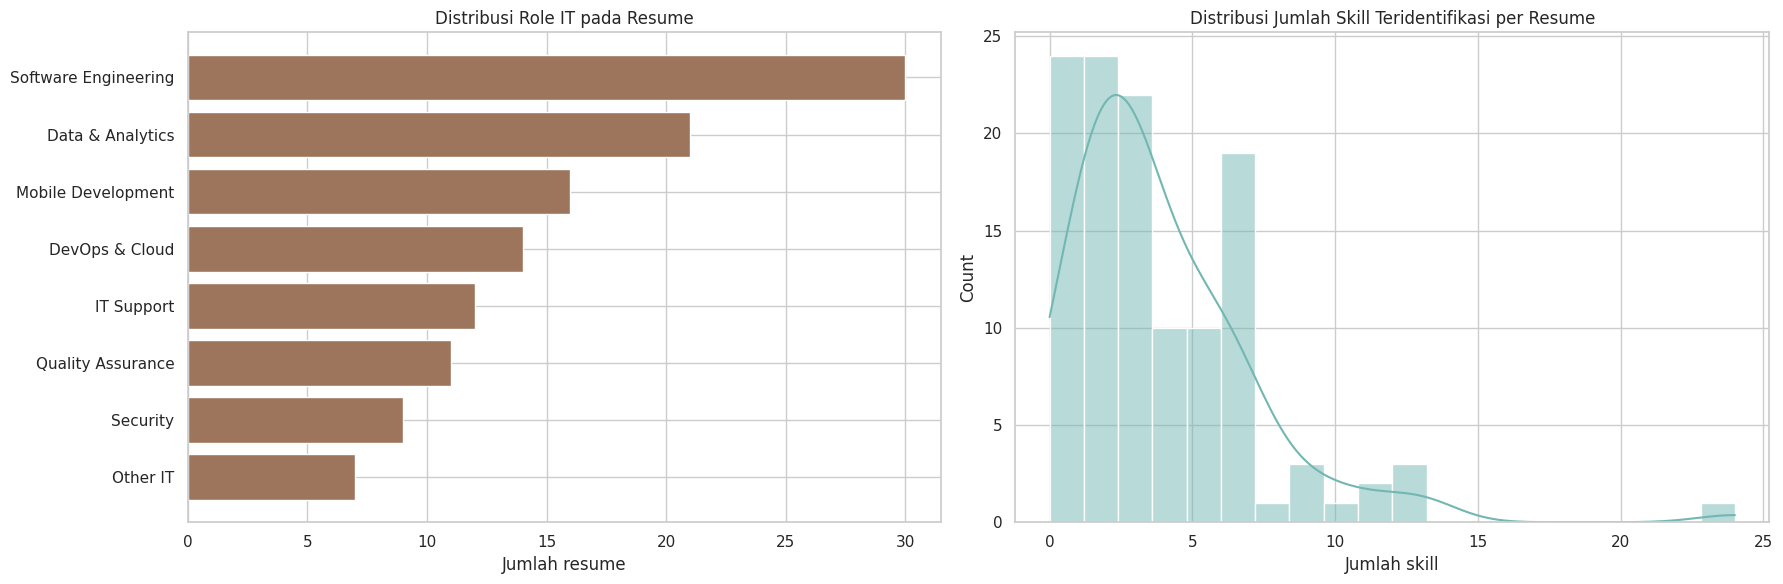

Resume role counts:
 role_bucket
Other IT                 7
Security                 9
Quality Assurance       11
IT Support              12
DevOps & Cloud          14
Mobile Development      16
Data & Analytics        21
Software Engineering    30

Resume skill count summary:
 count    120.000000
mean       3.941667
std        3.401176
min        0.000000
25%        2.000000
50%        3.000000
75%        5.250000
max       24.000000


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

resume_role_counts = resume_it['role_bucket'].value_counts().sort_values(ascending=True)
axes[0].barh(resume_role_counts.index, resume_role_counts.values, color='#9d755d')
axes[0].set_title('Distribusi Role IT pada Resume')
axes[0].set_xlabel('Jumlah resume')

sns.histplot(resume_it['skill_count'], bins=20, kde=True, ax=axes[1], color='#72b7b2')
axes[1].set_title('Distribusi Jumlah Skill Teridentifikasi per Resume')
axes[1].set_xlabel('Jumlah skill')

plt.tight_layout()
plt.show()

print('Resume role counts:\n', resume_role_counts.to_string())
print('\nResume skill count summary:\n', resume_it['skill_count'].describe().to_string())

### EDA 6 - Demand vs Supply Skill

Tahap ini membandingkan skill yang diminta lowongan dengan skill yang muncul pada resume. Dari sini kita bisa melihat skill mana yang paling banyak dicari pasar tetapi belum banyak dikuasai kandidat.

           skill  job_mentions  resume_mentions  gap_mentions
             SQL          2812             49.0        2763.0
          Python          2663              7.0        2656.0
             AWS          1899              5.0        1894.0
            Java          1761             13.0        1748.0
           Azure          1569              5.0        1564.0
      JavaScript          1451             10.0        1441.0
           CI/CD           933              0.0         933.0
              C#           851              8.0         843.0
            HTML           836             22.0         814.0
              Go           811              8.0         803.0
      Kubernetes           810              0.0         810.0
Machine Learning           798              0.0         798.0
           Excel           797             30.0         767.0
          Docker           774              0.0         774.0
             C++           750             11.0         739.0


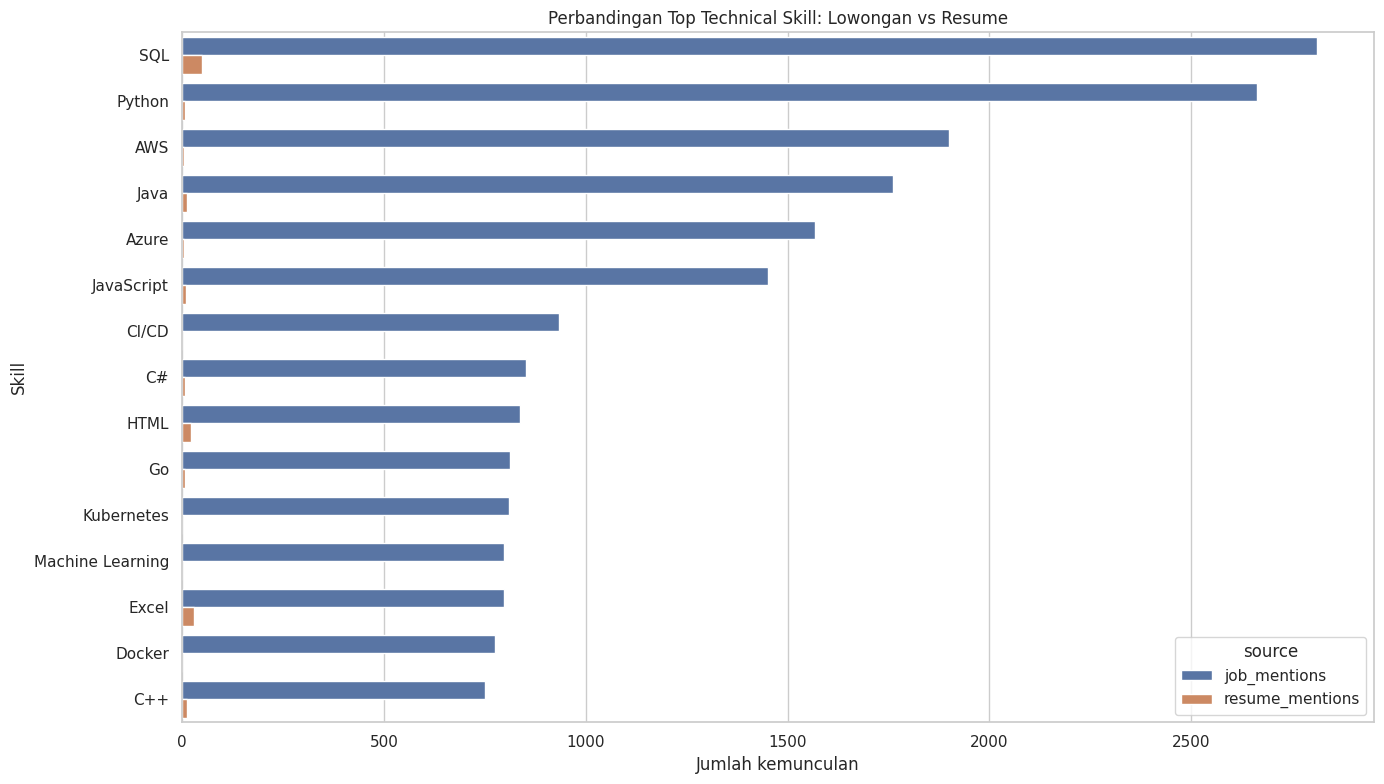

In [ ]:
job_skill_long = (
    job_it[['role_bucket', 'skills_extracted']]
    .explode('skills_extracted')
    .rename(columns={'skills_extracted': 'skill'})
    .dropna(subset=['skill'])
)
resume_skill_long = (
    resume_it[['role_bucket', 'skills_extracted']]
    .explode('skills_extracted')
    .rename(columns={'skills_extracted': 'skill'})
    .dropna(subset=['skill'])
)

job_skill_long_tech = job_skill_long[job_skill_long['skill'].isin(TECHNICAL_SKILL_SET)].copy()
resume_skill_long_tech = resume_skill_long[resume_skill_long['skill'].isin(TECHNICAL_SKILL_SET)].copy()

job_skill_freq_tech = job_skill_long_tech['skill'].value_counts().rename_axis('skill').reset_index(name='job_mentions')
resume_skill_freq_tech = resume_skill_long_tech['skill'].value_counts().rename_axis('skill').reset_index(name='resume_mentions')

skill_compare = job_skill_freq_tech.merge(resume_skill_freq_tech, on='skill', how='outer').fillna(0)
skill_compare['gap_mentions'] = skill_compare['job_mentions'] - skill_compare['resume_mentions']
skill_compare = skill_compare.sort_values('job_mentions', ascending=False).head(15)

print(skill_compare.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 8))
plot_df = skill_compare.melt(id_vars='skill', value_vars=['job_mentions', 'resume_mentions'], var_name='source', value_name='count')
sns.barplot(data=plot_df, y='skill', x='count', hue='source', ax=ax)
ax.set_title('Perbandingan Top Technical Skill: Lowongan vs Resume')
ax.set_xlabel('Jumlah kemunculan')
ax.set_ylabel('Skill')
plt.tight_layout()
plt.show()

## Visualisasi

Bagian ini merangkum visual terbaik dari EDA agar insight utama bisa dibaca cepat. Visual yang ditampilkan dipilih karena langsung mendukung jawaban dari pertanyaan bisnis.

### Visualisasi 1 - Top Technical Skill

Pertama, kita tampilkan skill teknis yang paling sering muncul pada lowongan IT dan resume IT. Perbandingan ini membantu melihat skill mana yang paling dominan di sisi demand dan supply.

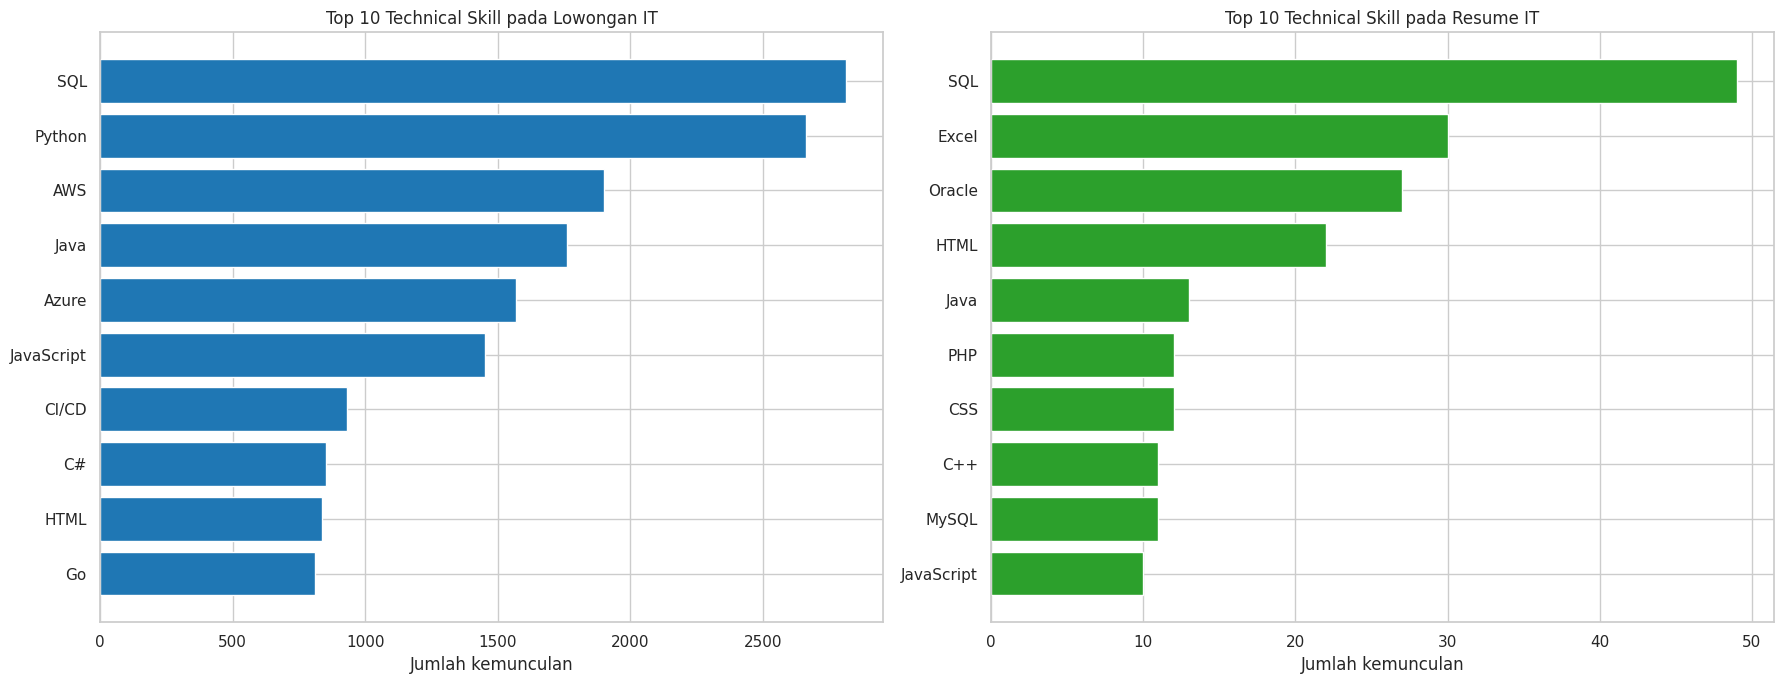

In [ ]:
top_job_skill = job_skill_freq_tech.sort_values('job_mentions', ascending=False).head(10)
top_resume_skill = resume_skill_freq_tech.sort_values('resume_mentions', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].barh(top_job_skill['skill'][::-1], top_job_skill['job_mentions'][::-1], color='#1f77b4')
axes[0].set_title('Top 10 Technical Skill pada Lowongan IT')
axes[0].set_xlabel('Jumlah kemunculan')

axes[1].barh(top_resume_skill['skill'][::-1], top_resume_skill['resume_mentions'][::-1], color='#2ca02c')
axes[1].set_title('Top 10 Technical Skill pada Resume IT')
axes[1].set_xlabel('Jumlah kemunculan')

plt.tight_layout()
plt.show()

### Visualisasi 2 - Supply dan Demand per Role

Visual berikut membandingkan jumlah lowongan dan resume untuk tiap role IT. Dari sini kita bisa melihat role mana yang paling timpang dan perlu menjadi prioritas analisis gap.

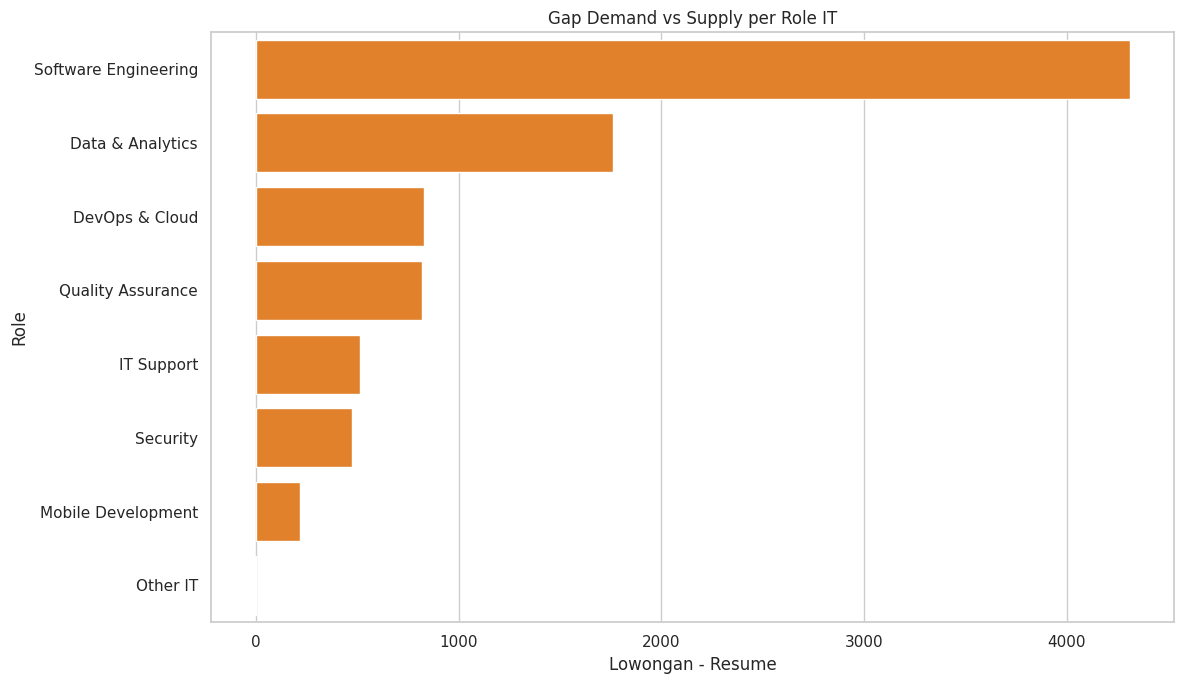

         role_bucket  job_postings  resume_count  supply_demand_ratio  demand_supply_gap
Software Engineering        4344.0            30             0.006906             4314.0
    Data & Analytics        1784.0            21             0.011771             1763.0
      DevOps & Cloud         842.0            14             0.016627              828.0
   Quality Assurance         828.0            11             0.013285              817.0
          IT Support         524.0            12             0.022901              512.0
            Security         479.0             9             0.018789              470.0
  Mobile Development         232.0            16             0.068966              216.0
            Other IT           0.0             7                  NaN               -7.0


In [ ]:
role_supply_demand = (
    job_it.groupby('role_bucket').agg(job_postings=('role_bucket', 'size')).reset_index()
    .merge(
        resume_it.groupby('role_bucket').agg(resume_count=('role_bucket', 'size')).reset_index(),
        on='role_bucket',
        how='outer'
    )
    .fillna(0)
)
role_supply_demand['supply_demand_ratio'] = np.where(role_supply_demand['job_postings'] > 0, role_supply_demand['resume_count'] / role_supply_demand['job_postings'], np.nan)
role_supply_demand['demand_supply_gap'] = role_supply_demand['job_postings'] - role_supply_demand['resume_count']

role_plot = role_supply_demand.sort_values('demand_supply_gap', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=role_plot, y='role_bucket', x='demand_supply_gap', color='#ff7f0e', ax=ax)
ax.set_title('Gap Demand vs Supply per Role IT')
ax.set_xlabel('Lowongan - Resume')
ax.set_ylabel('Role')
plt.tight_layout()
plt.show()

print(role_supply_demand.sort_values('demand_supply_gap', ascending=False).to_string(index=False))

### Visualisasi 3 - Skill Gap per Role

Visual terakhir menunjukkan skill gap paling besar di setiap role IT. Fokusnya adalah skill teknis yang paling sering diminta di lowongan tetapi belum banyak muncul di resume.

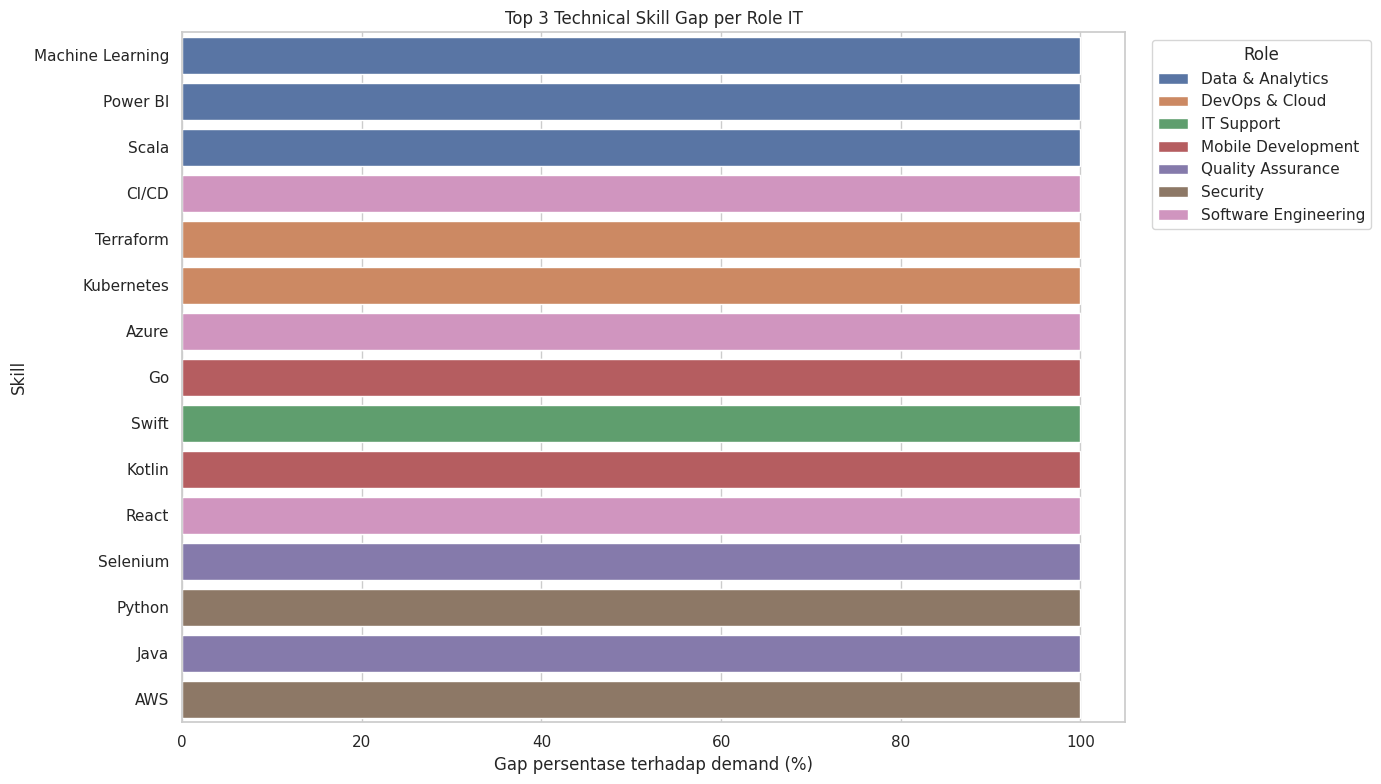

         role_bucket            skill  job_mentions  resume_mentions  gap_mentions  gap_pct
    Data & Analytics Machine Learning           523              0.0         523.0    100.0
    Data & Analytics         Power BI           220              0.0         220.0    100.0
    Data & Analytics            Scala           167              0.0         167.0    100.0
      DevOps & Cloud            CI/CD           246              0.0         246.0    100.0
      DevOps & Cloud        Terraform           237              0.0         237.0    100.0
      DevOps & Cloud       Kubernetes           228              0.0         228.0    100.0
          IT Support            Azure            44              0.0          44.0    100.0
          IT Support               Go            35              0.0          35.0    100.0
          IT Support            Swift            31              0.0          31.0    100.0
  Mobile Development           Kotlin            16              0.0          16

In [ ]:
skill_gap_tech = (
    job_skill_long_tech.groupby(['role_bucket', 'skill']).size().reset_index(name='job_mentions')
    .merge(
        resume_skill_long_tech.groupby(['role_bucket', 'skill']).size().reset_index(name='resume_mentions'),
        on=['role_bucket', 'skill'],
        how='left'
    )
    .fillna({'resume_mentions': 0})
)
skill_gap_tech['gap_mentions'] = skill_gap_tech['job_mentions'] - skill_gap_tech['resume_mentions']
skill_gap_tech['gap_pct'] = np.where(skill_gap_tech['job_mentions'] > 0, skill_gap_tech['gap_mentions'].clip(lower=0) / skill_gap_tech['job_mentions'] * 100, 0)

skill_gap_top = skill_gap_tech.sort_values(['role_bucket', 'gap_pct', 'job_mentions'], ascending=[True, False, False]).groupby('role_bucket').head(3)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(data=skill_gap_top, y='skill', x='gap_pct', hue='role_bucket', dodge=False, ax=ax)
ax.set_title('Top 3 Technical Skill Gap per Role IT')
ax.set_xlabel('Gap persentase terhadap demand (%)')
ax.set_ylabel('Skill')
ax.legend(title='Role', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(skill_gap_top.sort_values(['role_bucket', 'gap_pct'], ascending=[True, False]).to_string(index=False))

### Ringkasan Visual

**Pertanyaan bisnis 1: Skill teknis apa saja yang paling sering muncul pada lowongan IT di dataset ini, dan berapa persentase kemunculan masing-masing skill terhadap total lowongan IT?**

Berdasarkan visual top technical skill, kebutuhan pasar paling terkonsentrasi pada skill inti seperti SQL, Python, AWS, Java, Azure, JavaScript, CI/CD, C#, HTML, dan Go. Polanya menunjukkan bahwa lowongan IT tidak menyebar merata ke semua skill, tetapi terkumpul pada kombinasi skill programming, cloud, dan engineering workflow. Artinya, kandidat yang ingin masuk ke industri IT sebaiknya memprioritaskan skill dasar yang muncul berulang di banyak lowongan, terutama SQL dan Python untuk data-oriented role, serta AWS, Azure, dan CI/CD untuk role yang lebih infrastrukturnya kuat.

**Pertanyaan bisnis 2: Untuk setiap role IT utama di dataset, skill apa yang paling sering diminta oleh lowongan tetapi paling jarang muncul pada resume kandidat, dan seberapa besar gap-nya dalam persentase?**

Dari visual skill gap per role, gap terbesar terlihat pada role Software Engineering, Data & Analytics, dan DevOps & Cloud. Di role Data & Analytics, skill seperti Machine Learning, Power BI, dan Scala muncul kuat di lowongan tetapi hampir tidak terlihat pada resume, sehingga gap-nya sangat tinggi. Di role DevOps & Cloud, CI/CD, Terraform, dan Kubernetes juga dominan di lowongan namun sangat minim di resume. Pola serupa terjadi pada Software Engineering, misalnya Azure, React, CI/CD, dan Docker, yang menunjukkan bahwa supply kandidat belum mengejar kebutuhan teknis yang benar-benar dicari pasar.

**Pertanyaan bisnis 3: Role IT mana yang memiliki ketidakseimbangan supply-demand paling tinggi, diukur dari rasio jumlah resume IT terhadap jumlah lowongan IT, sehingga dapat diprioritaskan dalam rekomendasi pengembangan karier?**

Berdasarkan visual supply-demand per role, role dengan demand terbesar sekaligus supply paling kecil adalah Software Engineering, lalu Data & Analytics, DevOps & Cloud, Quality Assurance, IT Support, dan Security. Software Engineering memiliki jumlah lowongan paling tinggi, tetapi resume yang terdeteksi untuk role ini masih jauh lebih sedikit dibanding demand-nya. Dengan kata lain, gap supply-demand paling besar justru berada di role yang paling banyak dibutuhkan industri. Ini berarti rekomendasi pengembangan karier sebaiknya diprioritaskan ke role yang paling dominan di pasar, karena peluang serapannya paling besar dan kebutuhan skill-nya paling jelas terlihat dari data.

Secara keseluruhan, visualisasi mendukung satu kesimpulan utama: pasar kerja IT pada dataset ini sangat kuat pada skill teknis inti, sementara supply kandidat belum merata pada role-role yang paling banyak dicari. Karena itu, learning path dan rekomendasi karier sebaiknya difokuskan pada skill yang paling sering muncul di lowongan dan paling besar gap-nya di resume kandidat.

## Simpan Output

Tahap terakhir adalah menyimpan seluruh hasil olahan data. File yang disimpan mencakup data yang sudah difilter ke IT, tabel eksplorasi, ringkasan skill, tabel gap, dan data dictionary agar bisa langsung dipakai tim AI Engineer.

In [ ]:
output_files = {
    'it_job_postings_filtered.csv': job_it,
    'it_resume_filtered.csv': resume_it,
    'it_job_skill_freq_technical.csv': job_skill_freq_tech,
    'it_resume_skill_freq_technical.csv': resume_skill_freq_tech,
    'it_role_supply_demand.csv': role_supply_demand,
    'it_skill_gap_technical.csv': skill_gap_tech,
    'it_data_dictionary.csv': pd.DataFrame([
        {'file_name': 'it_job_postings_filtered.csv', 'description': 'Data lowongan yang sudah difilter ke industri IT'},
        {'file_name': 'it_resume_filtered.csv', 'description': 'Data resume yang sudah difilter ke industri IT'},
        {'file_name': 'it_job_skill_freq_technical.csv', 'description': 'Frekuensi technical skill pada lowongan IT'},
        {'file_name': 'it_resume_skill_freq_technical.csv', 'description': 'Frekuensi technical skill pada resume IT'},
        {'file_name': 'it_role_supply_demand.csv', 'description': 'Ringkasan supply-demand per role IT'},
        {'file_name': 'it_skill_gap_technical.csv', 'description': 'Gap technical skill per role IT'},
        {'file_name': 'it_job_features_model_ready.csv', 'description': 'Dataset lowongan model-ready tanpa label target'},
        {'file_name': 'it_resume_features_model_ready.csv', 'description': 'Dataset resume model-ready tanpa label target'},
    ])
}

job_features = job_it.drop(columns=['role_bucket', 'skills_extracted', 'skill_count', 'it_flag'])
resume_features = resume_it.drop(columns=['role_bucket', 'skills_extracted', 'skill_count', 'it_flag'])
job_features.to_csv(OUTPUT_DIR / 'it_job_features_model_ready.csv', index=False)
resume_features.to_csv(OUTPUT_DIR / 'it_resume_features_model_ready.csv', index=False)

for filename, table in output_files.items():
    table.to_csv(OUTPUT_DIR / filename, index=False)

print('Saved files:')
for filename in output_files:
    print('-', OUTPUT_DIR / filename)
print('-', OUTPUT_DIR / 'it_job_features_model_ready.csv')
print('-', OUTPUT_DIR / 'it_resume_features_model_ready.csv')

Saved files:
- output/it_job_postings_filtered.csv
- output/it_resume_filtered.csv
- output/it_job_skill_freq_technical.csv
- output/it_resume_skill_freq_technical.csv
- output/it_role_supply_demand.csv
- output/it_skill_gap_technical.csv
- output/it_data_dictionary.csv
- output/it_job_features_model_ready.csv
- output/it_resume_features_model_ready.csv
